In [2]:
import pandas as pd
df =pd.read_csv('payments_data.csv', usecols = ['Loan_ID','loan_status', 'Principal', 'past_due_days','age'])

In [3]:
df.isnull().sum()

Loan_ID            0
loan_status        0
Principal          0
past_due_days    300
age                0
dtype: int64

In [4]:
df.isnull().mean()

Loan_ID          0.0
loan_status      0.0
Principal        0.0
past_due_days    0.6
age              0.0
dtype: float64

In [5]:
df.head()

,Loan_ID,loan_status,Principal,past_due_days,age
0,xqd20166231,PAIDOFF,1000,NaN,45
1,xqd20168902,PAIDOFF,1000,NaN,50
2,xqd20160003,PAIDOFF,1000,NaN,33
3,xqd20160004,PAIDOFF,1000,NaN,27
4,xqd20160005,PAIDOFF,1000,NaN,28


In [6]:
df.isnull().mean().sort_values(ascending = True)

Loan_ID          0.0
loan_status      0.0
Principal        0.0
age              0.0
past_due_days    0.6
dtype: float64

<AxesSubplot:>

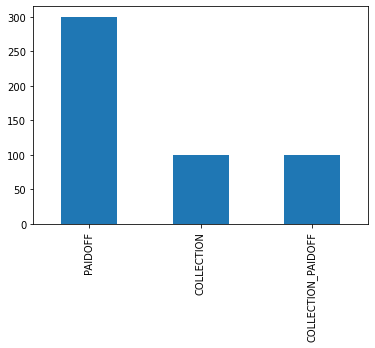

In [7]:
df['loan_status'].value_counts().plot.bar()

<AxesSubplot:>

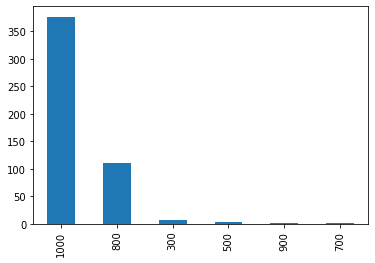

In [8]:
df['Principal'].value_counts().plot.bar()

<AxesSubplot:xlabel='Principal'>

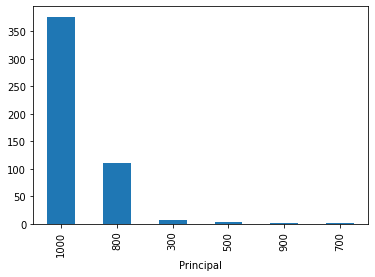

In [9]:
df.groupby(['Principal'])['Principal'].count().sort_values(ascending = False).plot.bar()

In [10]:
df['loan_status'].value_counts().index[0]

'PAIDOFF'

In [11]:
def impute_nan(df, variable):
    most_frequent_category = df[variable].value_counts().index[0]
    df[variable].fillna(most_frequent_category, inplace = True)


In [12]:
for feature in ['Loan_ID','loan_status','Principal','past_due_days']:
    impute_nan(df,feature)

In [13]:
df.isnull().mean()

Loan_ID          0.0
loan_status      0.0
Principal        0.0
past_due_days    0.0
age              0.0
dtype: float64

# Adding variables which consists of another variables to find NaN values

In [14]:
df2=pd.read_csv('payments_data.csv')
df2.head()

,Loan_ID,loan_status,Principal,terms,effective_date,due_date,paid_off_time,past_due_days,age,education,Gender
0,xqd20166231,PAIDOFF,1000,30,9/8/2016,10/7/2016,9/14/2016 19:31,NaN,45,High School or Below,male
1,xqd20168902,PAIDOFF,1000,30,9/8/2016,10/7/2016,10/7/2016 9:00,NaN,50,Bechalor,female
2,xqd20160003,PAIDOFF,1000,30,9/8/2016,10/7/2016,9/25/2016 16:58,NaN,33,Bechalor,female
3,xqd20160004,PAIDOFF,1000,15,9/8/2016,9/22/2016,9/22/2016 20:00,NaN,27,college,male
4,xqd20160005,PAIDOFF,1000,30,9/9/2016,10/8/2016,9/23/2016 21:36,NaN,28,college,female


In [15]:
import numpy as np
df2['loan_status']=np.where(df2['past_due_days'].isnull(),1,0)

In [16]:
frequent = df2['loan_status'].mode()[0]


In [17]:
df2['loan_status'].fillna(frequent,inplace=True)
df2.head()

,Loan_ID,loan_status,Principal,terms,effective_date,due_date,paid_off_time,past_due_days,age,education,Gender
0,xqd20166231,1,1000,30,9/8/2016,10/7/2016,9/14/2016 19:31,NaN,45,High School or Below,male
1,xqd20168902,1,1000,30,9/8/2016,10/7/2016,10/7/2016 9:00,NaN,50,Bechalor,female
2,xqd20160003,1,1000,30,9/8/2016,10/7/2016,9/25/2016 16:58,NaN,33,Bechalor,female
3,xqd20160004,1,1000,15,9/8/2016,9/22/2016,9/22/2016 20:00,NaN,27,college,male
4,xqd20160005,1,1000,30,9/9/2016,10/8/2016,9/23/2016 21:36,NaN,28,college,female


#Handle Categorical Column Missing Data




###  Replacing NAN values with the most frequent occurred category in variable/column.

In [18]:
df2['Qu_Var'] = np.where(df2['paid_off_time'].isnull(), 1, 0)
frequent = df2['paid_off_time'].mode()[0]
df2['paid_off_time'].fillna(frequent, inplace = True)

In [19]:
df2.head(10)

,Loan_ID,loan_status,Principal,terms,effective_date,due_date,paid_off_time,past_due_days,age,education,Gender,Qu_Var
0,xqd20166231,1,1000,30,9/8/2016,10/7/2016,9/14/2016 19:31,NaN,45,High School or Below,male,0
1,xqd20168902,1,1000,30,9/8/2016,10/7/2016,10/7/2016 9:00,NaN,50,Bechalor,female,0
2,xqd20160003,1,1000,30,9/8/2016,10/7/2016,9/25/2016 16:58,NaN,33,Bechalor,female,0
3,xqd20160004,1,1000,15,9/8/2016,9/22/2016,9/22/2016 20:00,NaN,27,college,male,0
4,xqd20160005,1,1000,30,9/9/2016,10/8/2016,9/23/2016 21:36,NaN,28,college,female,0
5,xqd20160706,1,300,7,9/9/2016,9/15/2016,9/9/2016 13:45,NaN,35,Master or Above,male,0
6,xqd20160007,1,1000,30,9/9/2016,10/8/2016,10/7/2016 23:07,NaN,29,college,male,0
7,xqd20160008,1,1000,30,9/9/2016,10/8/2016,10/5/2016 20:33,NaN,36,college,male,0
8,xqd20160909,1,1000,30,9/9/2016,10/8/2016,10/8/2016 16:00,NaN,28,college,male,0
9,xqd20160010,1,800,15,9/10/2016,9/24/2016,9/24/2016 13:00,NaN,26,college,male,0


In [20]:
df3=pd.read_csv('payments_data.csv')

In [21]:
def impute_nan(df, column_variable):
    df[column_variable+'newvar']= np.where(df[column_variable].isnull(),'Missing', df[column_variable])



In [22]:
for feature in ['Loan_ID','Principal','terms']:
    impute_nan(df3, feature)

In [23]:

df3=df3.drop(['Loan_ID','Principal','terms'],axis=1)

In [24]:
df3.head()

,loan_status,effective_date,due_date,paid_off_time,past_due_days,age,education,Gender,Loan_IDnewvar,Principalnewvar,termsnewvar
0,PAIDOFF,9/8/2016,10/7/2016,9/14/2016 19:31,NaN,45,High School or Below,male,xqd20166231,1000,30
1,PAIDOFF,9/8/2016,10/7/2016,10/7/2016 9:00,NaN,50,Bechalor,female,xqd20168902,1000,30
2,PAIDOFF,9/8/2016,10/7/2016,9/25/2016 16:58,NaN,33,Bechalor,female,xqd20160003,1000,30
3,PAIDOFF,9/8/2016,9/22/2016,9/22/2016 20:00,NaN,27,college,male,xqd20160004,1000,15
4,PAIDOFF,9/9/2016,10/8/2016,9/23/2016 21:36,NaN,28,college,female,xqd20160005,1000,30


Advantage: Simple and easy to implement for categorical variables/columns.

Disadvantage:

Features having a max number of null values may bias prediction if replace with the most occurred category.
It distorts the relation of the most frequent label.